# Support Vector Machines

In Lesson 04, we learned how Logistic Regression uses the Sigmoid function to draw a Decision Boundary between two classes. However, Logistic Regression is satisfied with *any* line that separates the data—even if that line passes dangerously close to the data points, leaving no room for error.

**Support Vector Machines (SVMs)** take a much more rigorous approach. An SVM does not just want to separate the data; it wants to separate the data with the **Maximum Margin** possible. It behaves like a cautious engineer drawing a safety zone between two classes, ensuring that future, unseen data has the highest mathematical probability of falling on the correct side of the line.

SVM is a powerful Supervised Learning algorithm capable of performing both linear and non-linear classification. It is widely considered one of the most elegant algorithms in machine learning because its optimization objective relies entirely on profound geometric principles.

Let's set up our Python environment to visualize the geometry of the Maximum Margin.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.svm import SVC
from sklearn.datasets import make_blobs, make_circles

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Advanced Geometric Modeling Environment Ready.")

✅ Advanced Geometric Modeling Environment Ready.


# 1. The Mathematics of the Margin

In SVM, we do not just draw a single Decision Boundary. We draw a "street." The center line of the street is the Decision Boundary (the Hyperplane), and the two edges of the street are the **Margins**.

### The Hyperplane
For a dataset with $n$ features, the Hyperplane is defined by a weight vector $w$ (which determines the orientation of the plane) and a bias $b$ (which determines its offset from the origin):
$$w^T x - b = 0$$

### The Margins
We define the two edges of our "street" mathematically. We want to push these edges as far outward as possible until they physically "bump" into the closest data points.
*   Positive Margin: $w^T x - b = 1$
*   Negative Margin: $w^T x - b = -1$

The data points that exactly touch these margins are called the **Support Vectors**. They are the *only* data points that matter. If you deleted every other data point in the dataset, the SVM boundary would not change. The algorithm is entirely "supported" by these critical boundary points.

### The Optimization Problem
Using vector geometry, we can prove that the physical distance (the width of the street) between these two margins is exactly $\frac{2}{||w||}$ (where $||w||$ is the magnitude of the weight vector). 

To maximize the width of the street, we must minimize $||w||$. Therefore, the optimization objective of an SVM is to find $w$ and $b$ that:
**Minimize:**
$$\frac{1}{2} ||w||^2$$
**Subject to the constraint:**
$$y^{(i)} (w^T x^{(i)} - b) \ge 1 \quad \text{for all } i$$
*(This constraint mathematically enforces that every data point must land on the correct side of the street).*

# 2. Visualizing the Maximum Margin Classifier

Let's simulate a perfectly separable corporate dataset: classifying whether a server will **Pass** ($y=1$) or **Fail** ($y=0$) an extreme load test based on its **CPU Cores** and **RAM**. 

We will train a Linear SVM and explicitly highlight the Support Vectors that dictate the boundary.

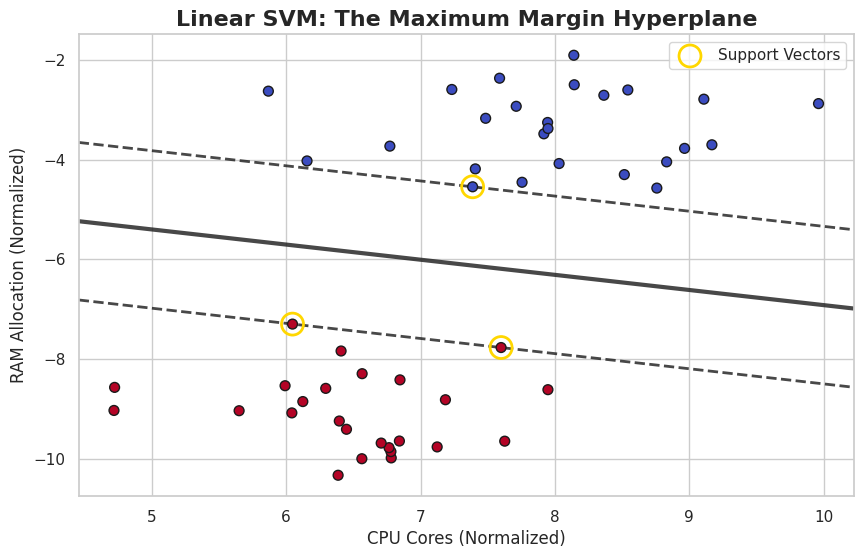

In [2]:
# 1. Simulate perfectly separable Server Data
X, y = make_blobs(n_samples=50, centers=2, random_state=6, cluster_std=0.8)

# 2. Train the Support Vector Classifier (Linear Kernel)
# C=1000 forces a "Hard Margin" (no misclassifications allowed)
svm_model = SVC(kernel='linear', C=1000)
svm_model.fit(X, y)

# 3. Matplotlib Visualization of the Math
plt.figure(figsize=(10, 6))

# Plot the raw data
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='coolwarm', edgecolors='k', zorder=3)

# Create a grid to evaluate the model
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

# Get the distance to the separating hyperplane for every point on the grid
Z = svm_model.decision_function(xy).reshape(XX.shape)

# Plot the Hyperplane and the Margins
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.8,
           linestyles=['--', '-', '--'], linewidths=[2, 3, 2], zorder=2)

# Highlight the Support Vectors
support_vectors = svm_model.support_vectors_
ax.scatter(support_vectors[:, 0], support_vectors[:, 1], s=250,
           linewidth=2, facecolors='none', edgecolors='gold', label='Support Vectors', zorder=4)

plt.title("Linear SVM: The Maximum Margin Hyperplane", fontsize=16, fontweight='bold')
plt.xlabel("CPU Cores (Normalized)")
plt.ylabel("RAM Allocation (Normalized)")
plt.legend()
plt.show()

*(Insight: Look at the data points enclosed in the gold rings. Those are the Support Vectors. The solid black line is the Hyperplane. Notice how the dashed lines (the Margins) are pushed outward as far as mathematically possible until they hit those specific gold points. The SVM has created the safest possible boundary between the two classes.)*

# 3. The Soft Margin & The $C$ Hyperparameter

In the real world, data is rarely perfectly separable. There will always be a few outliers (e.g., a server with massive RAM that still failed). If we force the SVM to draw a "Hard Margin" that perfectly separates everything, the boundary will contort wildly to accommodate one outlier, leading to **Overfitting**.

To solve this, we introduce **Slack Variables ($\zeta$)** into our optimization math, allowing the model to make a few intentional mistakes if it results in a wider, more robust street overall. 

This tolerance is controlled by the **Hyperparameter $C$** (Regularization):
*   **High $C$ (e.g., $C=1000$)**: Strict. Narrow margin. Heavily penalizes misclassifications. High Variance (Risk of Overfitting).
*   **Low $C$ (e.g., $C=0.01$)**: Lenient. Wide margin. Willingly ignores outliers to maintain a smooth boundary. High Bias (Risk of Underfitting).

# 4. The Kernel Trick (Non-Linear Data)

What happens if our data cannot be separated by a straight line? Imagine a dataset where Class 1 is a tight cluster of points in the center, and Class 0 forms a ring completely surrounding it. No straight line can separate a circle.

SVMs solve this using the profoundly brilliant **Kernel Trick**. 
Instead of trying to draw a curved line in 2D space, the Kernel Trick mathematically projects the 2D data into a 3D space (adding a $Z$-axis, like dropping a heavy ball onto a trampoline). In this 3D space, the data *can* be sliced by a flat, linear plane. When we project that flat slice back down to 2D, it looks like a perfect circle!

The most common kernel is the **RBF (Radial Basis Function) Kernel**.

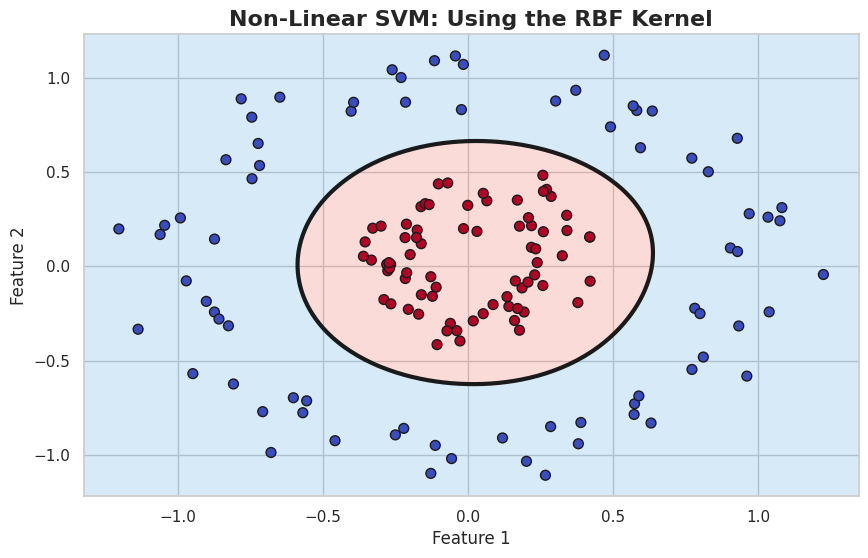

In [3]:
# 1. Simulate non-linear data (Circles)
X_circ, y_circ = make_circles(n_samples=150, factor=0.3, noise=0.1, random_state=42)

# 2. Train an SVM using the RBF Kernel
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_rbf.fit(X_circ, y_circ)

# 3. Matplotlib Visualization
plt.figure(figsize=(10, 6))
plt.scatter(X_circ[:, 0], X_circ[:, 1], c=y_circ, s=50, cmap='coolwarm', edgecolors='k', zorder=3)

# Create grid for non-linear boundaries
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
xx = np.linspace(xlim[0], xlim[1], 100)
yy = np.linspace(ylim[0], ylim[1], 100)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z_rbf = svm_rbf.decision_function(xy).reshape(XX.shape)

# Plot the Non-Linear Margin
ax.contourf(XX, YY, Z_rbf, levels=[-100, 0, 100], alpha=0.2, colors=['#3498db', '#e74c3c'], zorder=1)
ax.contour(XX, YY, Z_rbf, colors='k', levels=[0], alpha=1.0, linestyles=['-'], linewidths=[3], zorder=2)

plt.title("Non-Linear SVM: Using the RBF Kernel", fontsize=16, fontweight='bold')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

*(Insight: The solid black line perfectly separates the red inner circle from the blue outer ring. The SVM did not actually draw a circle. It used the RBF Kernel to mathematically warp the space, sliced it with a flat plane, and projected it back down to us.)*

## Real-World Use Case or Analogy:
Think of Support Vector Machines like **Building a Highway Between Two Hostile Countries**:

*   **Logistic Regression**: Would just paint a thin white line on the dirt exactly halfway between the closest soldiers. If someone accidentally trips over the line, a war starts. It has zero safety buffer.
*   **The Support Vectors**: The military outposts stationed closest to the border. The SVM only cares about these outposts. It completely ignores the cities thousands of miles inland.
*   **The Maximum Margin**: The SVM builds a heavily fortified, massive Demilitarized Zone (DMZ) between the two countries. It pushes the walls of the DMZ outward until they physically touch the nearest outposts. 
*   **The Soft Margin ($C$)**: If one rogue soldier pitches a tent far across the border, a Strict SVM (High $C$) will build a massive, zigzagging wall around that single tent to ensure it stays separated. A Lenient SVM (Low $C$) will just bulldoze over the tent, accepting one casualty to ensure the border wall remains straight, smooth, and easily defensible.

---